In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import pandas as pd
import numpy as np
import copy
from datetime import datetime
import copy

from src.paths import BM_RESULTS_DIR, ABM_SIM_RES_DIR, ABM_SWEEP_RES_DIR
from src.config import load_abm_sim_cfg, load_abm_sweep_cfg
from abm.flow_field import FlowField
from abm.endothelial_cell import EndothelialCell
from abm.rho_lookup_table import RhoLookupTable
from abm.scripts.run_abm_sim import run_abm_sim_single, run_abm_sim, get_perb_cfg
from abm.scripts.run_abm_sweep import *

cfg = load_abm_sim_cfg()
sweep_cfg = load_abm_sweep_cfg()

lut  = RhoLookupTable(cfg, BM_RESULTS_DIR)


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437


# Testing

In [2]:
test_cfg = copy.deepcopy(cfg)

test_cfg['mechanics']['rhoc_protrusion_gain'] = 5.0

ts, ss, _, _ = run_abm_sim(test_cfg, lut, n_steps=500)
wt_ar = ss.loc[ss['perturbation']=='WT', 'ar'].values[0]
ss['ratio'] = (ss['ar'] / wt_ar).round(3)
print(ss[['perturbation', 'ar', 'ratio', 'rho_balance',
          'mean_k_active', 'mean_lsf_ratio']].to_string(index=False))

 perturbation    ar  ratio  rho_balance  mean_k_active  mean_lsf_ratio
           WT 4.464  1.000       -0.007         2.3496          0.7724
       DSP_KO 6.091  1.364        0.541         1.0000          0.5962
      TJP1_KO 4.013  0.899       -0.538         3.5769          1.0000
      JCAD_KO 5.197  1.164       -0.013         1.4680          0.9100
 DSP_JCAD_DKO 5.894  1.320        0.239         1.0000          0.8070
TJP1_JCAD_DKO 5.283  1.183       -0.236         2.0907          1.0000


In [2]:
ts, ss, _, _ = run_abm_sim(cfg, lut, n_steps=500)
print(ss[['perturbation', 'ar', 'rho_balance', 
          'mean_k_active', 'mean_lsf_ratio']])

    perturbation     ar  rho_balance  mean_k_active  mean_lsf_ratio
0             WT  4.453       -0.007         2.3574          0.8548
1         DSP_KO  6.145        0.541         1.0000          0.7401
2        TJP1_KO  3.999       -0.538         3.5767          1.0000
3        JCAD_KO  5.187       -0.013         1.4711          0.9436
4   DSP_JCAD_DKO  5.914        0.239         1.0000          0.8774
5  TJP1_JCAD_DKO  5.271       -0.236         2.0906          1.0000


In [2]:
sweep_df = run_param_sweep(cfg, lut, sweep_cfg)
sweep_df

>>> INFO: Built 64 parameter combinations from 3 parameters: ['f_magnitude', 'rhoa_k_gain', 'rhoc_protrusion_gain']
>>> INFO: Starting ABM parameter sweep
>>> INFO: 64 combinations × 6 perturbations = 384 runs
>>> INFO: 1500 steps per run

>>> INFO: [1/64] {'f_magnitude': 8.0, 'rhoa_k_gain': 8.0, 'rhoc_protrusion_gain': 3.0}
>>> INFO: Running abm simulation perturbation: WT (1500 steps).
>>> INFO: Running abm simulation perturbation: DSP_KO (1500 steps).
>>> INFO: Running abm simulation perturbation: TJP1_KO (1500 steps).
>>> INFO: Running abm simulation perturbation: JCAD_KO (1500 steps).
>>> INFO: Running abm simulation perturbation: DSP_JCAD_DKO (1500 steps).
>>> INFO: Running abm simulation perturbation: TJP1_JCAD_DKO (1500 steps).
>>> INFO: All perturbations completed successfully.
    WT: ar=3.604  score=-inf  status=ordering_failed_DSP_JCAD_DKO_geq_DSP_KO
>>> INFO: [2/64] {'f_magnitude': 8.0, 'rhoa_k_gain': 8.0, 'rhoc_protrusion_gain': 4.0}
>>> INFO: Running abm simulation pertu

,f_magnitude,rhoa_k_gain,rhoc_protrusion_gain,perturbation,ar,ar_ratio,phenotype,rho_balance,mean_k_active,mean_lsf_ratio,mean_t_sf,combo_score,combo_status
0,8.0,8.0,6.0,TJP1_KO,3.248,0.8638,Failed,-0.538,3.6799,1.0000,0.0000,-0.265715,ok
1,8.0,8.0,6.0,DSP_KO,5.997,1.5949,Hyper,0.541,1.0000,0.6484,2.6004,-0.265715,ok
2,8.0,8.0,6.0,WT,3.760,1.0000,Normal,-0.007,2.4344,0.8072,1.4934,-0.265715,ok
3,8.0,8.0,6.0,TJP1_JCAD_DKO,4.528,1.2043,Normal,-0.236,2.1339,1.0000,0.0000,-0.265715,ok
4,8.0,8.0,6.0,DSP_JCAD_DKO,5.759,1.5316,Hyper,0.239,1.0000,0.8371,2.1431,-0.265715,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,12.0,8.0,3.0,DSP_JCAD_DKO,7.685,1.6495,Hyper,0.239,1.0000,0.8370,2.7337,-inf,ordering_failed_DSP_JCAD_DKO_geq_DSP_KO
380,12.0,8.0,3.0,TJP1_JCAD_DKO,6.112,1.3119,Normal,-0.236,2.1346,1.0000,0.0000,-inf,ordering_failed_DSP_JCAD_DKO_geq_DSP_KO
381,12.0,10.0,3.0,WT,4.324,1.0000,Normal,-0.007,2.7945,0.8071,1.7093,-inf,ordering_failed_DSP_JCAD_DKO_geq_DSP_KO
382,12.0,10.0,3.0,DSP_KO,7.585,1.7542,Hyper,0.541,1.0000,0.6481,3.0851,-inf,ordering_failed_DSP_JCAD_DKO_geq_DSP_KO


In [3]:
print(sweep_df[sweep_df['perturbation'] == 'WT'][
    ['f_magnitude', 'rhoa_k_gain', 'rhoc_protrusion_gain',
     'ar', 'combo_score', 'combo_status']
].head(10).to_string())

    f_magnitude  rhoa_k_gain  rhoc_protrusion_gain     ar  combo_score combo_status
2           8.0          8.0                   6.0  3.760    -0.265715           ok
6           8.0          8.0                   5.0  3.708    -0.266762           ok
16          8.0          8.0                   4.0  3.656    -0.267974           ok
22         10.0          8.0                   6.0  4.285    -0.297106           ok
28         10.0          8.0                   5.0  4.232    -0.298039           ok
30          8.0         10.0                   4.0  3.433    -0.298636           ok
36          8.0         10.0                   5.0  3.479    -0.298742           ok
47          8.0         10.0                   6.0  3.525    -0.298939           ok
52         10.0          8.0                   4.0  4.179    -0.299195           ok
59         12.0          8.0                   6.0  4.821    -0.323843           ok


In [4]:
params = list(sweep_cfg['param_ranges'].keys())

# Show top 5 combinations with all conditions
top_combos = (sweep_df[sweep_df['combo_status'] == 'ok']
              .drop_duplicates(subset=params)
              .sort_values('combo_score', ascending=False)
              .head(5))

exp_targets = sweep_cfg['exp_targets']

for _, top in top_combos.iterrows():
    mask = pd.Series([True] * len(sweep_df))
    for p in params:
        mask = mask & (sweep_df[p] == top[p])

    combo_df = sweep_df[mask].sort_values('ar')
    print(f"\nf={top['f_magnitude']} rhoa_k={top['rhoa_k_gain']} "
          f"rhoc_p={top['rhoc_protrusion_gain']} "
          f"score={top['combo_score']:.4f}")
    print(f"  {'Condition':<18} {'Model AR':>8} {'Exp AR':>8} "
          f"{'Ratio':>7} {'Phenotype':>10}")
    print(f"  {'-'*55}")
    for _, r in combo_df.iterrows():
        exp = exp_targets.get(r['perturbation'], None)
        exp_str = f"{exp:.3f}" if exp else "  —  "
        print(f"  {r['perturbation']:<18} {r['ar']:>8.3f} "
              f"{exp_str:>8} {r['ar_ratio']:>7.3f} "
              f"{r['phenotype']:>10}")


f=8.0 rhoa_k=8.0 rhoc_p=6.0 score=-0.2657
  Condition          Model AR   Exp AR   Ratio  Phenotype
  -------------------------------------------------------
  TJP1_KO               3.248    3.371   0.864     Failed
  WT                    3.760    5.403   1.000     Normal
  TJP1_JCAD_DKO         4.528    4.040   1.204     Normal
  JCAD_KO               4.639    5.437   1.234      Hyper
  DSP_JCAD_DKO          5.759    6.224   1.532      Hyper
  DSP_KO                5.997    7.047   1.595      Hyper

f=8.0 rhoa_k=8.0 rhoc_p=5.0 score=-0.2668
  Condition          Model AR   Exp AR   Ratio  Phenotype
  -------------------------------------------------------
  TJP1_KO               3.248    3.371   0.876     Failed
  WT                    3.708    5.403   1.000     Normal
  TJP1_JCAD_DKO         4.528    4.040   1.221     Normal
  JCAD_KO               4.609    5.437   1.243      Hyper
  DSP_JCAD_DKO          5.670    6.224   1.529      Hyper
  DSP_KO                5.805    7.047   1.5

# SIMULATION RUNS

## SINGLE SIM TEST

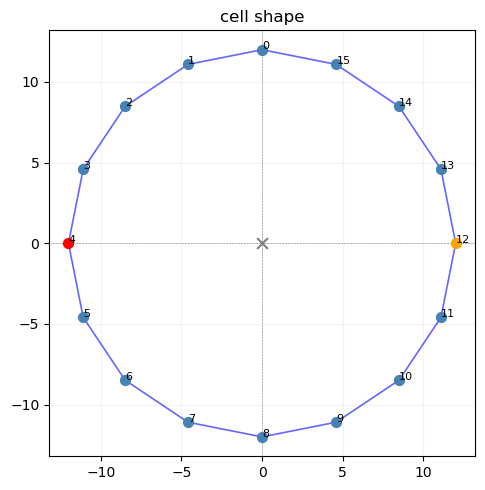

In [2]:
results = run_abm_sim_single(cfg, lut, 'WT', 500, True)

In [4]:
spring_df = results['spring_df']
spring_df[spring_df['id'] == 4]

,step,time,perturbation,id,L_current,L_cortex,L_sf,k_active,alignment,init_alignment,tension_cortex,tension_sf,tension_total,DSP,TJP1,JCAD,P_RhoA,P_RhoC
4,0,0.0,WT,4,4.6822,4.6822,4.6822,1.0000,0.195,0.195,0.0000,0.0000,0.0000,0.000,0.000,0.000,0.463,0.437
20,50,5.0,WT,4,7.7306,4.6822,4.6360,1.2170,0.924,0.195,3.6938,0.4164,4.1102,0.663,0.662,0.665,0.644,0.637
36,100,10.0,WT,4,7.6304,4.6822,4.5892,1.4620,0.947,0.195,4.2969,0.4093,4.7061,0.666,0.664,0.668,0.644,0.637
52,150,15.0,WT,4,7.4920,4.6822,4.5497,1.6692,0.954,0.195,4.6795,0.3960,5.0754,0.667,0.665,0.668,0.644,0.637
68,200,20.0,WT,4,7.4104,4.6822,4.5162,1.8446,0.954,0.195,5.0237,0.3895,5.4132,0.667,0.666,0.669,0.644,0.637
84,250,25.0,WT,4,7.3660,4.6822,4.4878,1.9931,0.954,0.195,5.3416,0.3874,5.7290,0.668,0.666,0.669,0.644,0.637
100,300,30.0,WT,4,7.3336,4.6822,4.4638,2.1187,0.954,0.195,5.6114,0.3862,5.9976,0.668,0.667,0.669,0.644,0.637
116,350,35.0,WT,4,7.2994,4.6822,4.4435,2.2250,0.954,0.195,5.8182,0.3844,6.2026,0.668,0.667,0.669,0.644,0.637
132,400,40.0,WT,4,7.2614,4.6822,4.4264,2.3149,0.953,0.195,5.9665,0.3816,6.3481,0.668,0.667,0.669,0.644,0.637
148,450,45.0,WT,4,7.2213,4.6822,4.4118,2.3910,0.952,0.195,6.0677,0.3782,6.4458,0.668,0.667,0.669,0.644,0.637


## Full Run + Save to df

In [5]:
ts, ss, spr_ts, spr_ss = run_abm_sim(cfg, lut, n_steps=500)

>>> INFO: Running abm simulation perturbation: WT (500 steps).
>>> INFO: Running abm simulation perturbation: DSP_KO (500 steps).
>>> INFO: Running abm simulation perturbation: TJP1_KO (500 steps).
>>> INFO: Running abm simulation perturbation: JCAD_KO (500 steps).
>>> INFO: Running abm simulation perturbation: DSP_JCAD_DKO (500 steps).
>>> INFO: Running abm simulation perturbation: TJP1_JCAD_DKO (500 steps).
>>> INFO: All perturbations completed successfully.


In [3]:
spr_ss


NameError: name 'spr_ss' is not defined

In [8]:
ss.loc[ss['perturbation'] == 'WT', 'ar'].values

array([4.453])

### Param Sweep Building

In [3]:
ss_df = ss.copy()
exp_targets = sweep_cfg['exp_targets']
order_consts = sweep_cfg['ordering_constraints']

# Build ar lookup from ss_df
ar = dict(zip(ss_df['perturbation'], ss_df['ar']))

In [4]:
exp_targets

{'WT': 5.403,
 'DSP_KO': 7.047,
 'TJP1_KO': 3.371,
 'JCAD_KO': 5.437,
 'DSP_JCAD_DKO': 6.224,
 'TJP1_JCAD_DKO': 4.04}

In [5]:
ar

{'WT': 4.453,
 'DSP_KO': 6.145,
 'TJP1_KO': 3.999,
 'JCAD_KO': 5.187,
 'DSP_JCAD_DKO': 5.914,
 'TJP1_JCAD_DKO': 5.271}

In [13]:
model_ratios = {}
exp_ratios = {}
maes = []
for perb in exp_targets:
    if perb not in ar:
        continue
    model_ratios[perb] = ar[perb] / ar['WT']
    exp_ratios[perb] = exp_targets[perb] / exp_targets['WT']
    mae = abs(model_ratios[perb] - exp_ratios[perb])
    maes.append(mae)

In [14]:
maes

[0.0,
 0.07569315796686027,
 0.27413361982237494,
 0.15853989676203106,
 0.1761408012507626,
 0.4359636433901385]

In [16]:
mean(maes)

NameError: name 'mean' is not defined